# Lab 4: Enhancing the Bike Sharing System

Welcome to **Lab 4** of the Modeling & Simulation course! In this laboratory session, we will build upon the foundations laid in the previous labs to enhance our bike-sharing system simulation. This lab introduces the concept of **time slot-specific probabilities**, allowing you to model varying bike usage patterns throughout the day. Additionally, you will implement bike maintenance and downtime, develop a rebalancing mechanism, track customer satisfaction, and undertake a **graded assignment** to design and implement a comprehensive simulation project.

---

## Table of Contents

1. [Recap of Previous Labs](#recap)
2. [Introduction to Time Slot-Specific Probabilities](#time-slots)
   - [Understanding Time Slots](#understanding-time-slots)
3. [Implementing Time Slot-Specific Probabilities](#implementing-time-slots)
   - [Defining Time Slots](#defining-time-slots)
4. [Graded Assignment Overview](#assignment)

---

## <a name="recap"></a>1. Recap of Previous Labs

### Lab 1: Python Introduction
- Gained proficiency in Python programming.
- Learned fundamental programming concepts such as variables, data types, control structures, functions, and basic I/O operations.

### Lab 2: Basic Bike Sharing System Modeling
- Developed a simplified bike-sharing system using Python classes.
- Modeled entities such as stations, bikes, and trips.
- Implemented basic trip generation and analyzed system behavior over a short period.

### Lab 3: Introduction to SimPy
- Introduced SimPy, a discrete-event simulation library in Python.
- Reimplemented the bike-sharing system using SimPy constructs like environments, processes, and resources.
- Explored extensions including variable trip durations, rebalancing strategies, and customer satisfaction tracking.

---

## <a name="time-slots"></a>2. Introduction to Time Slot-Specific Probabilities

In real-world scenarios, bike usage varies throughout the day. To simulate this variability, we introduce **time slot-specific probabilities**. This enhancement allows the simulation to reflect different demand levels during various periods, such as morning rush hours and midday.

### <a name="understanding-time-slots"></a>Understanding Time Slots

- **Time Slots:** Defined periods within a day where bike trip probabilities differ.
- **Recurring Pattern:** Time slots repeat every simulated day, enabling multi-day simulations.
- **Example Time Slots:**
  - **Morning Start (0-120 minutes):** Initial hours with increasing demand.
  - **Midday (120-720 minutes):** Peak hours with stable high demand.

### <a name="mapping-time"></a>Mapping Simulation Time to Real-Time

To create realistic simulations, map simulation minutes to actual day times.

- **Simulation Start Time:** 6:00 AM
- **Morning Start:** 6:00 AM - 8:00 AM (0-120 minutes)
- **Midday:** 8:00 AM - 6:00 PM (120-720 minutes)
- **Simulation Duration:** 20 days (12 hours/day) → 14400 minutes

---

## <a name="implementing-time-slots"></a>3. Implementing Time Slot-Specific Probabilities

### <a name="defining-time-slots"></a>Defining Time Slots

Define time slots with specific trip probability matrices within a single day. Use the modulo operation to map the current simulation time to the appropriate time slot.

```python
# Define time slots for a single day
time_slots = [
    {
        'name': 'morning_start',
        'start': 0,       # 0 minutes into the day (6:00 AM)
        'end': 120,       # 2 hours
        'prob_matrix': {
            ('A', 'B'): 0.4,
            ('B', 'A'): 0.6,
            ('A', 'C'): 0.2,
            ('C', 'A'): 0.5,
            ('B', 'C'): 0.3,
            ('C', 'B'): 0.4,
            ('A', 'D'): 0.3,
            ('D', 'A'): 0.2,
        }
    },
    {
        'name': 'midday',
        'start': 120,      # 2 hours into the day (8:00 AM)
        'end': 720,        # 12 hours total (6:00 PM)
        'prob_matrix': {
            ('A', 'B'): 0.2,
            ('B', 'A'): 0.3,
            ('A', 'C'): 0.1,
            ('C', 'A'): 0.2,
            ('B', 'C'): 0.25,
            ('C', 'B'): 0.35,
            ('A', 'D'): 0.15,
            ('D', 'A'): 0.25,
        }
    }
    # Add more time slots if needed
]

# Define default probability matrix if no slot matches
default_prob_matrix = {
    ('A', 'B'): 0.05,
    ('B', 'A'): 0.05,
    ('A', 'C'): 0.05,
    ('C', 'A'): 0.05,
    ('B', 'C'): 0.05,
    ('C', 'B'): 0.05,
    ('A', 'D'): 0.05,
    ('D', 'A'): 0.05,
}


In [ ]:
# Start from the code you've implemented in lab 3, add time-slot specific probabilities below
# Write your multi-run simulation & plotting code below
import random
import simpy
# Add a global variable tracking unhappy customers and increment it on each new unhappy customer
unhappy_customers = 0
import random
import matplotlib.pyplot as plt
# Defining the Station Class
class Station:
    def __init__(self, env, name, capacity, init_bikes):
        self.env = env
        self.name = name
        self.capacity = capacity
        self.bikes = simpy.Container(env, init=init_bikes, capacity=capacity)
env = simpy.Environment()

upt_station = Station(env, "UPT", capacity=10, init_bikes=5)
center_station = Station(env, "Center", capacity=10, init_bikes=5)
station_p700=Station(env, "P700", capacity=7, init_bikes=3)
train_station=Station(env, "Train", capacity=15, init_bikes=9)
stations = [upt_station, center_station, station_p700, train_station]

        # Define trip probabilities
prob_matrix = {
        (upt_station, center_station): 0.3,
        (center_station, upt_station): 0.5,
        (upt_station, station_p700): 0.2,
        (center_station, station_p700): 0.1,
        (station_p700, train_station): 0.4,
        (train_station, station_p700): 0.3,
   }
bike_levels = {station.name: [] for station in stations}
time_slots_probabilities= [{
    'name': 'morning',
    'star_time':0,
    'end_time': 120,
    'prob_matrix':
    {
        (upt_station, center_station): 0.4,
        (center_station, upt_station): 0.6,
        (upt_station, station_p700): 0.3,
        (center_station, station_p700): 0.2,
        (station_p700, train_station): 0.5,
        (train_station, station_p700): 0.4,
    }

},
{
    'name':'midday',
    'star_time':120,
    'end_time': 720,
    'prob_matrix':
    {
        (upt_station, center_station): 0.2,
        (center_station, upt_station): 0.3,
        (upt_station, station_p700): 0.1,
        (center_station, station_p700): 0.05,
        (station_p700, train_station): 0.2,
        (train_station, station_p700): 0.1,
    }
}
]

default_matrix={
    (upt_station, center_station): 0.05,
    (center_station, upt_station): 0.05,
    (upt_station, station_p700): 0.05,
    (center_station, station_p700): 0.05,
    (station_p700, train_station): 0.05,
    (train_station, station_p700): 0.05,
}


## <a name="assignment"></a>Graded Assignment Overview

Design and implement an enhanced bike-sharing system simulation using **SimPy**, incorporating advanced features to model a realistic and complex environment. Your simulation should build upon the concepts learned in previous labs and include the following components:

---

Your simulation must include the following elements:

### 1. Multiple Stations:

- **Minimum of Four stations** with varying capacities and initial bike counts.
- Each station should have a unique name, capacity, and initial number of bikes.

### 2. Time-Dependent Trip Probabilities:

- Implement trip probabilities that change based on different time slots (e.g., morning start, midday).
- Define at least **two distinct time slots** with different probability matrices.
- Ensure that time slots are **recurring daily** over the simulation period.

### 3. Bike Maintenance and Downtime:

- Model bike failures with a specified failure probability during trips.
- Implement a repair process that handles broken bikes, making them unavailable until repaired. The implementation details are up to your imagination.
- Track and report the number of bikes under maintenance.

### 4. Rebalancing Mechanism:

- Develop a rebalancing strategy to redistribute bikes between stations based on current demand and bike levels.
- Rebalancing should occur at regular intervals (e.g., every 20 minutes) and follow defined criteria.

### 5. Customer Satisfaction Tracking:

- Track the number of **unhappy customers** who cannot rent a bike due to unavailability.
- Track the number of **unhappy customers** who cannot return a bike due to full stations.

### 6. Data Collection and Visualization:

- Collect data on **bike levels** at each station over time.
- Collect data on **broken bikes** and maintenance activities.
- Collect data on **customer satisfaction** metrics.
- Generate plots to visualize:
  - **Bike levels** at each station over time.
  - **Number of bikes under maintenance**.
  - **Customer satisfaction metrics** (e.g., unhappy customers over time).

### 7. Simulation:

- Allow the simulation to run for a configurable duration (e.g., **20 days**).
- Parameters such as the number of stations, capacities, initial bikes, trip probabilities, maintenance rates, rebalancing intervals, and simulation duration should be easily adjustable.
- Simulate and observe the system with various parameters.

---

#### (Optional) Money Earning Mechanism:

- Introduce a system where the bike-sharing service earns **money based on bike rentals** (e.g., per hour rented).
- Track and report **total earnings** over the simulation period.

## What to Look For in Your Simulations

The primary objective of this lab is to enable you to create a realistic and dynamic simulation of a bike-sharing system that accounts for daily usage patterns, system maintenance, and operational strategies. Things to look for:

* Bike Availability: Assess how well the rebalancing mechanism maintains adequate bike levels across stations.
* Maintenance Impact: Evaluate the effect of bike failures on system performance and customer satisfaction.
* Customer Satisfaction: Analyze the number of unhappy customers and identify patterns or causes.

Write down a couple of observations from your simulations to accompany the presentation of your system.

## Grading

You will present your work in the upcoming laboratory, showing your system implementation and 1-3 simulations that you ran. The simulations should be accompanied by visual plots and you are encouraged to present any interesting observations about your system (e.g. with environment setup X the customer dissatisfaction drops significantly when increasing the rebalancing frequency to value y).

The project grade will be determined by the grade of completion of your system (how much of the project task has been implemented), as well as your understanding of it. The latter will be assessed through some basic questions about your model/system/simulations.

*Note: Where not strongly specified, you are free to design a subsystem/idea however you find best fit, e.g. points 2, 3 and 4 can have many different subsystem designs. There is no one correct way to do it.

In [10]:
#1
import simpy
import random

import matplotlib.pyplot as plt
failure_probability=0.3

# The Environment in SimPy manages the simulation time and handles event scheduling. It acts as the central controller of the simulation.
env = simpy.Environment()
class Bike:
    def __init__(self,bike_id,broken_or_not=False):
        self.bike_id=bike_id
        self.broken_or_not=broken_or_not
# Defining the Station Class
class Station:
    def __init__(self, env, name, capacity, init_bikes):
        self.env = env
        self.name = name
        self.capacity = capacity
        self.bikes = simpy.FilterStore(env, capacity=capacity)
        for i in range(init_bikes):
            self.bikes.put(Bike(f"{name}_Bike_{i}"))
    


In [11]:
def repair_in_ride(bike, customers):
    prob = random.uniform(0.0, 1.0)
    if failure_probability > prob:
        bike.broken_or_not = True
        customers['number_of_broken'] += 1
        return True
    else:
        if customers['number_of_broken'] > 0:
            customers['number_of_broken'] -= 1
        return False


def bike_trip(env, from_station, to_station, customers):
    global unhappy_customers_fullstation, unhappy_customers_unavailability
    if len(from_station.bikes.items) > 0:
        bike = yield from_station.bikes.get(lambda b: not b.broken_or_not)
        customers['customer_satisfaction'] += 1

        if repair_in_ride(bike, customers):
            customers['broken_bikes'] += 1
            yield env.timeout(30)
            bike.broken_or_not = False
    else:
        unhappy_customers_unavailability += 1
        customers['failed_pickups'] += 1
        return

    trip_duration = random.randint(1, 15)
    yield env.timeout(trip_duration)

    if len(to_station.bikes.items) < to_station.capacity:
        yield to_station.bikes.put(bike)
    else:
        customers['failed_returns'] += 1
        unhappy_customers_fullstation += 1
        yield env.timeout(trip_duration)
        if len(from_station.bikes.items) < from_station.capacity:
            yield from_station.bikes.put(bike)


def generate_trips(env, time_slots_probabilities, default_matrix, customers):
    while True:
        current_time = env.now % 720
        current_prob_matrix = default_matrix

        for slot in time_slots_probabilities:
            if slot['star_time'] <= current_time < slot['end_time']:
                current_prob_matrix = slot['prob_matrix']
                break

        for (from_station, to_station), prob in current_prob_matrix.items():
            if random.uniform(0, 1) < prob:
                env.process(bike_trip(env, from_station, to_station, customers))

        yield env.timeout(5)

In [12]:

def rebalace_stations(env, stations):
    while True:
        low_number=[s for s in stations if len(s.bikes.items) < s.capacity*0.4]
        big_number=[s for s in stations if len(s.bikes.items) > s.capacity*0.6]
        for lowN in low_number:
            for highN in big_number:
                if len(highN.bikes.items) > len(lowN.bikes.items) and len(lowN.bikes.items) > 0:
                    bike = yield highN.bikes.get(lambda b: not b.broken_or_not)                    
                    yield env.timeout(2)
                    yield lowN.bikes.put(bike)
        
        yield env.timeout(20)



Rularea 1:
  Rata de succes: 64.58%
  Clienți fără bicicletă: 10010
  Clienți fără doc: 56
  Biciclete stricate: 5510


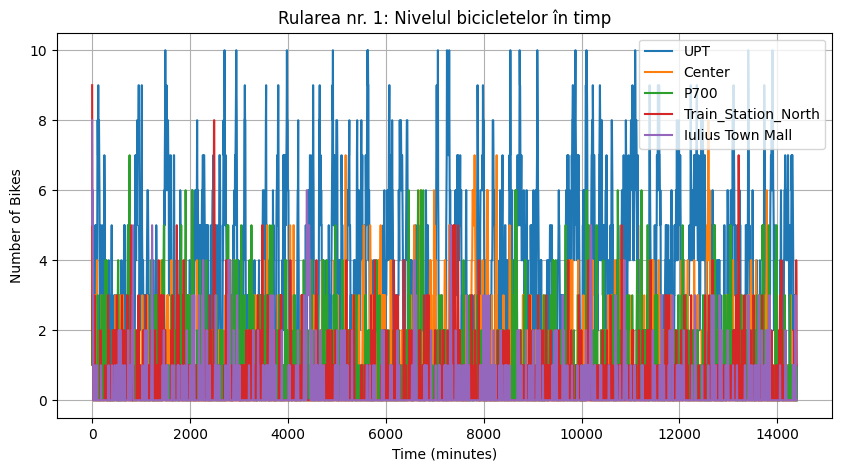

Rularea 2:
  Rata de succes: 64.08%
  Clienți fără bicicletă: 10146
  Clienți fără doc: 81
  Biciclete stricate: 5437


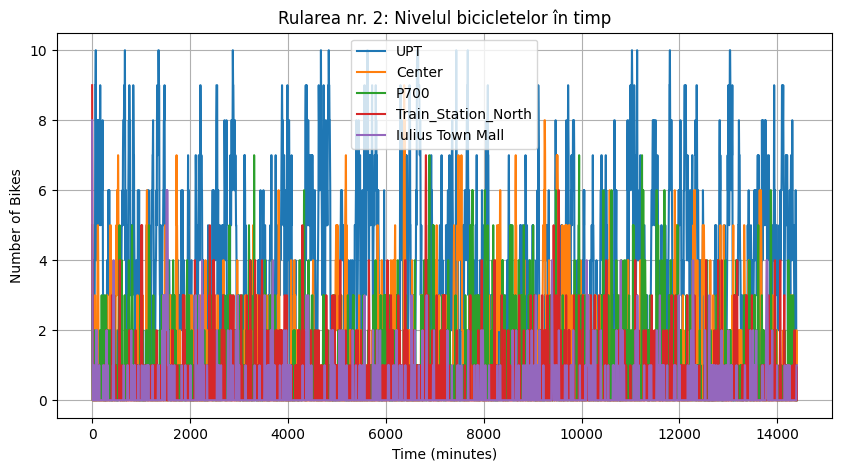

Rularea 3:
  Rata de succes: 64.42%
  Clienți fără bicicletă: 10111
  Clienți fără doc: 56
  Biciclete stricate: 5536


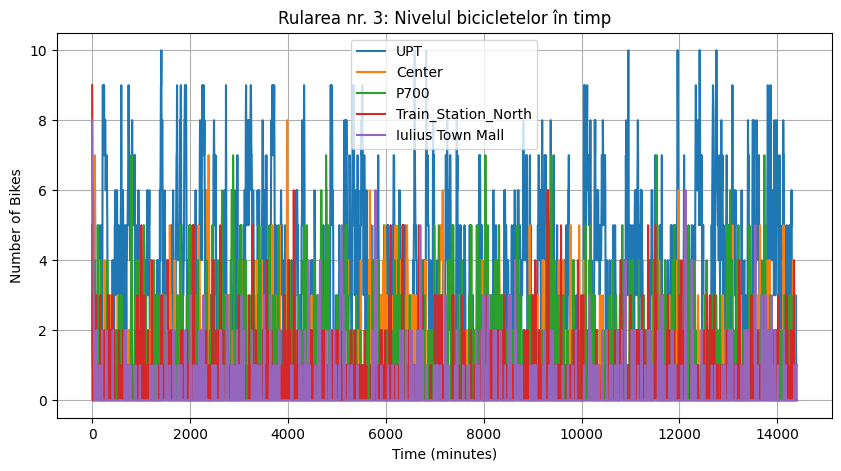

Rularea 4:
  Rata de succes: 64.84%
  Clienți fără bicicletă: 9947
  Clienți fără doc: 74
  Biciclete stricate: 5479


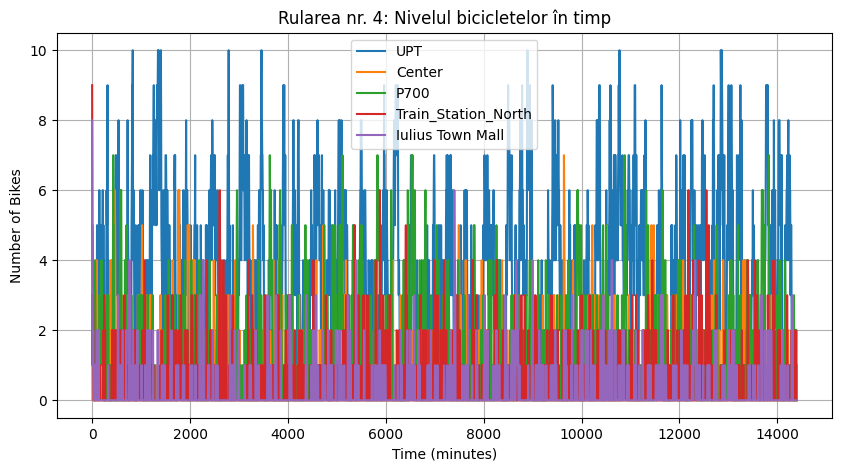

Rularea 5:
  Rata de succes: 64.86%
  Clienți fără bicicletă: 9967
  Clienți fără doc: 70
  Biciclete stricate: 5448


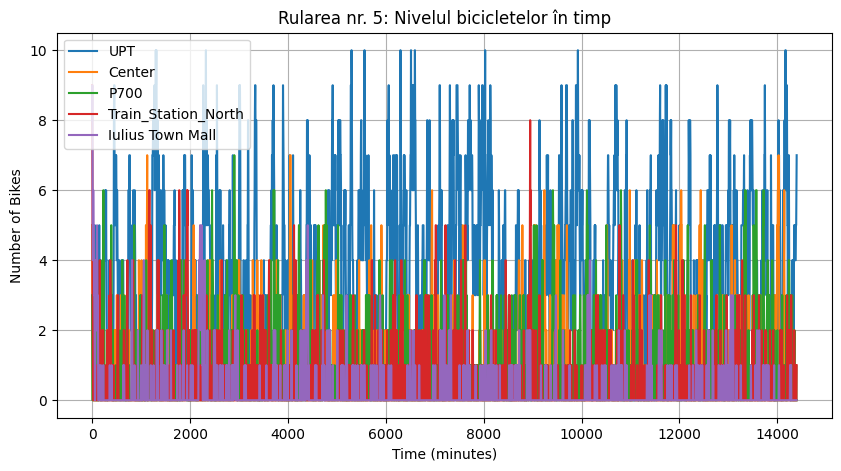

Rularea 6:
  Rata de succes: 64.39%
  Clienți fără bicicletă: 10136
  Clienți fără doc: 67
  Biciclete stricate: 5493


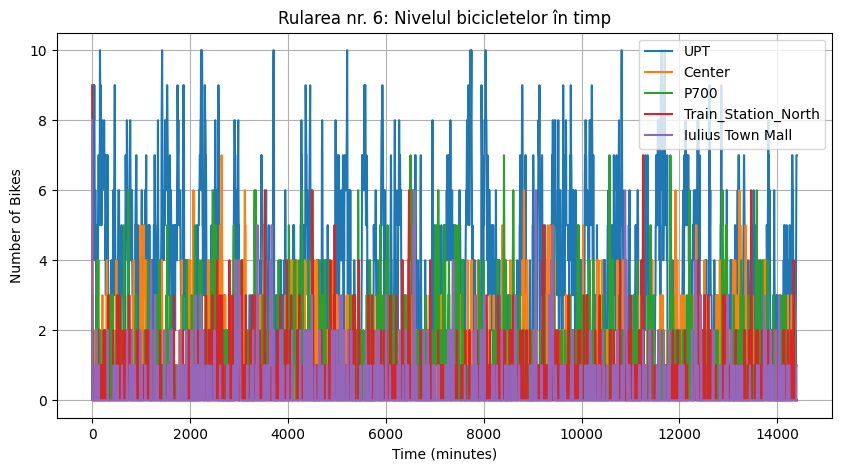

Rularea 7:
  Rata de succes: 65.24%
  Clienți fără bicicletă: 9901
  Clienți fără doc: 53
  Biciclete stricate: 5483


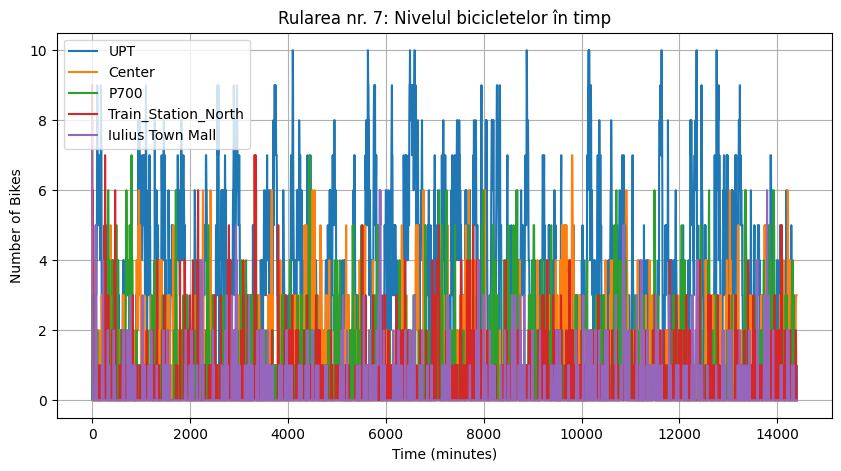

In [15]:
station_level = {}

def monitorizare(env, stations):
    for s in stations:
        station_level[s.name] = []
    while True:
        for s in stations:
            station_level[s.name].append((s.env.now, len(s.bikes.items)))
        yield env.timeout(5)


def multiple_runs(run_number):
    global station_level
    station_level = {}

    env = simpy.Environment()

    unhappy_customers_unavailability = 0
    unhappy_customers_fullstation = 0
    number_of_broken = 0
    customers = {
        'customer_satisfaction': 0,
        'failed_pickups': 0,
        'failed_returns': 0,
        'broken_bikes': 0,
        'number_of_broken': 0
    }

    upt_station = Station(env, "UPT", capacity=10, init_bikes=5)
    center_station = Station(env, "Center", capacity=10, init_bikes=5)
    station_p700 = Station(env, "P700", capacity=7, init_bikes=3)
    train_station_north = Station(env, "Train_Station_North", capacity=15, init_bikes=9)
    iulius_mall = Station(env, "Iulius Town Mall", capacity=20, init_bikes=8)
    current_stations = [upt_station, center_station, station_p700, train_station_north, iulius_mall]

    time_slots_probabilities = [
        {
            'name': 'morning',
            'star_time': 0,
            'end_time': 120,
            'prob_matrix': {
                (upt_station, center_station): 0.4,
                (center_station, upt_station): 0.6,
                (upt_station, station_p700): 0.3,
                (station_p700, upt_station): 0.1,
                (upt_station, train_station_north): 0.2,
                (train_station_north, upt_station): 0.7,
                (upt_station, iulius_mall): 0.4,
                (iulius_mall, upt_station): 0.35,
                (center_station, station_p700): 0.25,
                (station_p700, center_station): 0.4,
                (center_station, iulius_mall): 0.55,
                (iulius_mall, center_station): 0.4,
                (center_station, train_station_north): 0.75,
                (train_station_north, center_station): 0.9,
                (station_p700, train_station_north): 0.55,
                (train_station_north, station_p700): 0.4,
                (iulius_mall, station_p700): 0.5,
                (station_p700, iulius_mall): 0.2,
                (iulius_mall, train_station_north): 0.35,
                (train_station_north, iulius_mall): 0.4,
            }
        },
        {
            'name': 'noon',
            'star_time': 120,
            'end_time': 360,
            'prob_matrix': {
                (upt_station, center_station): 0.3,
                (center_station, upt_station): 0.1,
                (upt_station, station_p700): 0.27,
                (station_p700, upt_station): 0.26,
                (upt_station, train_station_north): 0.45,
                (train_station_north, upt_station): 0.75,
                (upt_station, iulius_mall): 0.45,
                (iulius_mall, upt_station): 0.65,
                (center_station, station_p700): 0.65,
                (station_p700, center_station): 0.55,
                (center_station, iulius_mall): 0.25,
                (iulius_mall, center_station): 0.3,
                (center_station, train_station_north): 0.85,
                (train_station_north, center_station): 0.65,
                (station_p700, train_station_north): 0.85,
                (train_station_north, station_p700): 0.7,
                (iulius_mall, station_p700): 0.8,
                (station_p700, iulius_mall): 0.3,
                (iulius_mall, train_station_north): 0.45,
                (train_station_north, iulius_mall): 0.5,
            }
        },
        {
            'name': 'evening',
            'star_time': 360,
            'end_time': 720,
            'prob_matrix': {
                (upt_station, center_station): 0.3,
                (center_station, upt_station): 0.1,
                (upt_station, station_p700): 0.27,
                (station_p700, upt_station): 0.26,
                (upt_station, train_station_north): 0.45,
                (train_station_north, upt_station): 0.75,
                (upt_station, iulius_mall): 0.45,
                (iulius_mall, upt_station): 0.65,
                (center_station, station_p700): 0.65,
                (station_p700, center_station): 0.55,
                (center_station, iulius_mall): 0.25,
                (iulius_mall, center_station): 0.3,
                (center_station, train_station_north): 0.85,
                (train_station_north, center_station): 0.65,
                (station_p700, train_station_north): 0.85,
                (train_station_north, station_p700): 0.7,
                (iulius_mall, station_p700): 0.8,
                (station_p700, iulius_mall): 0.3,
                (iulius_mall, train_station_north): 0.45,
                (train_station_north, iulius_mall): 0.5,
            }
        }
    ]

    default_matrix = {
        (upt_station, center_station): 0.1,
        (center_station, upt_station): 0.1,
        (upt_station, station_p700): 0.1,
        (station_p700, upt_station): 0.1,
        (upt_station, train_station_north): 0.1,
        (train_station_north, upt_station): 0.1,
        (upt_station, iulius_mall): 0.1,
        (iulius_mall, upt_station): 0.1,
        (center_station, station_p700): 0.1,
        (station_p700, center_station): 0.1,
        (center_station, iulius_mall): 0.1,
        (iulius_mall, center_station): 0.1,
        (center_station, train_station_north): 0.1,
        (train_station_north, center_station): 0.1,
        (station_p700, train_station_north): 0.1,
        (train_station_north, station_p700): 0.1,
        (iulius_mall, station_p700): 0.1,
        (station_p700, iulius_mall): 0.1,
        (iulius_mall, train_station_north): 0.1,
        (train_station_north, iulius_mall): 0.1,
    }

    env.process(generate_trips(env, time_slots_probabilities, default_matrix, customers))
    env.process(monitorizare(env, current_stations))
    env.process(rebalace_stations(env, current_stations))

    env.run(until=14400)  # 20 zile * 720 minute

    total_attempts = customers['customer_satisfaction'] + customers['failed_pickups']
    success_rate = (customers['customer_satisfaction'] / total_attempts * 100) if total_attempts > 0 else 0

    plt.figure(figsize=(10, 5))
    for station_name, levels in station_level.items():
        times, counts = zip(*levels)
        plt.plot(times, counts, label=station_name)

    print(f"Rularea {run_number + 1}:")
    print(f"  Rata de succes: {success_rate:.2f}%")
    print(f"  Clienți fără bicicletă: {customers['failed_pickups']}")
    print(f"  Clienți fără doc: {customers['failed_returns']}")
    print(f"  Biciclete stricate: {customers['broken_bikes']}")

    plt.xlabel('Time (minutes)')
    plt.ylabel('Number of Bikes')
    plt.title(f'Rularea nr. {run_number + 1}: Nivelul bicicletelor în timp')
    plt.legend()
    plt.grid(True)
    plt.show()


for i in range(7):
    multiple_runs(i)